# Fetch planets' positions relative to ESMUC

In [ ]:
!pip3 install ephem


https://rhodesmill.org/pyephem/quick
https://rhodesmill.org/pyephem/radec
https://rhodesmill.org/pyephem/tutorial.html

In [2]:
def pretty(d, indent=0):
   for key, value in d.items():
      print('\t' * indent + str(key))
      if isinstance(value, dict):
         pretty(value, indent+1)
      else:
         print('\t' * (indent+1) + str(value))

## Get data

In [14]:
import ephem

planets = [
    ephem.Moon(),
    ephem.Mercury(),
    ephem.Venus(),
    ephem.Mars(),
    ephem.Jupiter(),
    ephem.Saturn(),
    ephem.Uranus()
]



measurings = dict.fromkeys((planet.name for planet in planets), {}) # Initialize dictionary

# Set up observing point
observer = ephem.Observer()
observer.name = "ESMUC"
observer.lat = '41.39858935189999'
observer.lon = '2.1853450576007365'
observer.elevation = 18  # meters
observer.pressure = 0


startingDate = ephem.Date('2016/06/17 00:00')
observer.date = startingDate - 2 * ephem.hour # ephem works with UTC. This accounts for the timezone

rangDies = 1  # days that the simulation will run
stepHores = 1 # how many hours are stepped
resolucio = 23 # bigger resolution = more results
resolucio = 24 - resolucio
print(int(rangDies * (24/resolucio)))

for i in range(int(rangDies * (24/resolucio))):
    for j, planet in enumerate(planets):
        planet.compute(observer)
        dateValues = dict({
            str(observer.date): {
                'separation': ephem.separation(observer, planet), 
                'mag': planet.mag, 
                'size': planet.size, 
                'alt': planet.alt, 
                'az': planet.az,
                'earth_distance': planet.earth_distance * 1000
                }
            })
            
        measurings[planet.name] =  {**measurings[planet.name], **dateValues}

        # print('%s measured from %s:' % (planet.name, observer.name))
        # print('%s, %s. Magnitude: %s, Size: %s' % (planet.ra, planet.dec, planet.mag, planet.size)) # Right Ascension, Declination (Apparent Topocentric Position, aka des del punt d'observació), magnitude
        # print(ephem.separation(observer, planet))
    observer.date += stepHores * ephem.hour

pretty((measurings))


24
Moon
	2016/6/16 22:00:00
		separation
			133:31:00.6
		mag
			-11.5
		size
			1792.8359375
		alt
			34:03:31.8
		az
			195:15:25.5
		earth_distance
			2.676330739632249
	2016/6/16 23:00:00
		separation
			133:22:06.9
		mag
			-11.52
		size
			1791.22119140625
		alt
			29:35:02.7
		az
			211:17:11.5
		earth_distance
			2.6787433307617903
	2016/6/17 00:00:00
		separation
			133:11:49.6
		mag
			-11.53
		size
			1788.4256591796875
		alt
			22:39:57.1
		az
			225:14:04.3
		earth_distance
			2.6829305570572615
	2016/6/17 01:00:00
		separation
			132:59:48.2
		mag
			-11.54
		size
			1784.6597900390625
		alt
			14:01:20.4
		az
			237:11:35.0
		earth_distance
			2.6885918341577053
	2016/6/17 02:00:00
		separation
			132:45:49.0
		mag
			-11.55
		size
			1780.197265625
		alt
			4:14:48.0
		az
			247:39:16.9
		earth_distance
			2.69533134996891
	2016/6/17 03:00:00
		separation
			132:29:45.1
		mag
			-11.56
		size
			1775.35302734375
		alt
			-6:13:14.5
		az
			257:12:44.1
		earth_distance
	

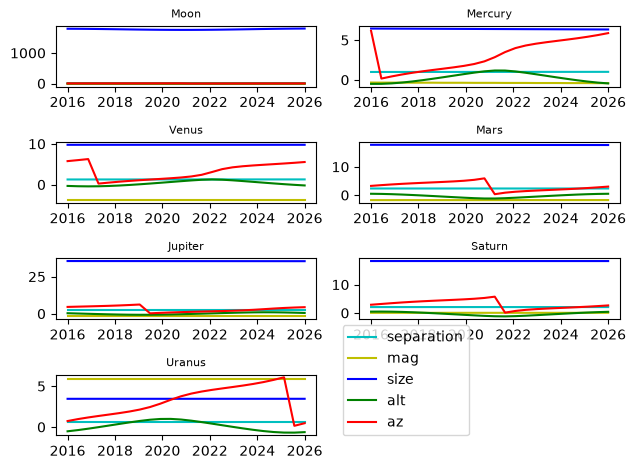

<class 'dict'>


In [ ]:
import matplotlib.pylab as plt
import numpy as np

xAxis = np.linspace(2016, 2026, int(rangDies * (24/resolucio))) # TODO: NO FORÇAR EL RANG
planetsArray = {}

for j, planet in enumerate(planets):
    values = {'separation': {}, 'mag': {}, 'size': {}, 'alt': {}, 'az': {}, 'distance': {}}

    for i in range(len(measurings[planet.name])):
        values["separation"][i] = list(measurings[planet.name].values())[i]["separation"]
        values["mag"][i] = list(measurings[planet.name].values())[i]["mag"]
        values["size"][i] = list(measurings[planet.name].values())[i]["size"]
        values["alt"][i] = list(measurings[planet.name].values())[i]["alt"]
        values["az"][i] = list(measurings[planet.name].values())[i]["az"]
        values["distance"][i] = list(measurings[planet.name].values())[i]["earth_distance"]

    # pretty(values)

    planetsArray[planet.name] = values

    ax = plt.subplot(4, 2, j+1)
    
    ax.plot(xAxis, values["separation"].values(), 'c', label="separation")
    ax.plot(xAxis, values["mag"].values(), 'y', label="mag")
    ax.plot(xAxis, values["size"].values(), 'b', label="size")
    ax.plot(xAxis, values["alt"].values(), 'g', label="alt")
    ax.plot(xAxis, values["az"].values(), 'r', label="az")
    ax.plot(xAxis, values["distance"].values(), 'm', label="distance")
    ax.set_title(planet.name, fontsize=8)


plt.tight_layout()
plt.legend(loc=(1.1,0))
plt.show()

print(type(planetsArray))

## Get planets within viewing scope

Good tools to check if calculations are correct: https://stellarium-web.org/, https://heavens-above.com/

In [15]:
# Using azalts

viewing_angle = ephem.degrees("20:00:00.0") # Minimum azimuth to consider a planet visible (higher az = higher in the sky)

visiblePlanets = {}

for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}

    for i, planet in enumerate(planets):
        thisPlanet = list(measurings[planet.name].values())[j]

        if(thisPlanet['alt'] > viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {
                'separation': thisPlanet['separation'], 
                'mag': thisPlanet['mag'],
                'size': thisPlanet['size'], 
                'alt': thisPlanet['alt'],
                'az': thisPlanet['az'], 
                'distance': thisPlanet['earth_distance'], 
                'time': time.split(" ")[1]
            }
    if(visiblePlanetsAtThisTime):
     visiblePlanets[time] = {**visiblePlanetsAtThisTime}

pretty(visiblePlanets)


2016/6/16 22:00:00
	Moon
		separation
			133:31:00.6
		mag
			-11.5
		size
			1792.8359375
		alt
			34:03:31.8
		az
			195:15:25.5
		distance
			2.676330739632249
		time
			22:00:00
	Mars
		separation
			134:06:02.0
		mag
			-1.77
		size
			17.785587310791016
		alt
			27:16:46.9
		az
			186:50:43.6
		distance
			526.2687802314758
		time
			22:00:00
	Saturn
		separation
			119:07:09.7
		mag
			0.05
		size
			18.31422996520996
		alt
			26:56:46.9
		az
			166:13:16.5
		distance
			9042.149543762207
		time
			22:00:00
2016/6/16 23:00:00
	Moon
		separation
			133:22:06.9
		mag
			-11.52
		size
			1791.22119140625
		alt
			29:35:02.7
		az
			211:17:11.5
		distance
			2.6787433307617903
		time
			23:00:00
	Mars
		separation
			134:06:24.5
		mag
			-1.77
		size
			17.781911849975586
		alt
			24:26:48.8
		az
			202:08:29.4
		distance
			526.3775587081909
		time
			23:00:00
	Saturn
		separation
			119:07:17.6
		mag
			0.05
		size
			18.313894271850586
		alt
			28:06:06.7
		az
			182:03:58.4
		di

# Fent servir OSC

In [ ]:
!pip3 install python-osc

In [16]:
from pythonosc import udp_client
import time as t
from datetime import datetime
import math

client = udp_client.SimpleUDPClient("127.0.0.1", 5050, timeout=10)



for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]

        outMessages = []

        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            print(planet, planetInfo)

            message = (
                "/"+planet, [
                    planetInfo['separation'],
                    planetInfo['mag'],
                    planetInfo['size'],
                    planetInfo['alt'],
                    planetInfo['az'],
                    planetInfo['distance'],
                    planetInfo['time']
                ]
            )
            outMessages.append(message)

        # print(notes_on, notes_off)
        for message in outMessages:
            # print('Sending message', message)
            client.send_message(*message)
        t.sleep(.2)


Moon {'separation': 2.3303081185963475, 'mag': -11.5, 'size': 1792.8359375, 'alt': 0.5944386720657349, 'az': 3.407879114151001, 'distance': 2.676330739632249, 'time': '22:00:00'}
Mars {'separation': 2.3404963449351084, 'mag': -1.77, 'size': 17.785587310791016, 'alt': 0.4761206805706024, 'az': 3.261068344116211, 'distance': 526.2687802314758, 'time': '22:00:00'}
Saturn {'separation': 2.0790248903078052, 'mag': 0.05, 'size': 18.31422996520996, 'alt': 0.470302551984787, 'az': 2.9011082649230957, 'distance': 9042.149543762207, 'time': '22:00:00'}
Moon {'separation': 2.327720837336875, 'mag': -11.52, 'size': 1791.22119140625, 'alt': 0.5163397789001465, 'az': 3.687645673751831, 'distance': 2.6787433307617903, 'time': '23:00:00'}
Mars {'separation': 2.3406050716320568, 'mag': -1.77, 'size': 17.781911849975586, 'alt': 0.4266785681247711, 'az': 3.5280346870422363, 'distance': 526.3775587081909, 'time': '23:00:00'}
Saturn {'separation': 2.079063291957672, 'mag': 0.05, 'size': 18.313894271850586,